In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

In [3]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

df = X.copy()
df["Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

Number of Samples: 150
Number of Features: 4


In [5]:
print("Feature Names:")
print(iris.feature_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print("Target Classes:")
print(iris.target_names)

Target Classes:
['setosa' 'versicolor' 'virginica']


In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
print(df["Species"].value_counts())

Species
0    50
1    50
2    50
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (120, 4)
Testing Features: (30, 4)
Training Labels: (120,)
Testing Labels: (30,)


In [12]:
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
dt = DecisionTreeClassifier(random_state=42)

In [15]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [16]:
y_pred = dt.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [19]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

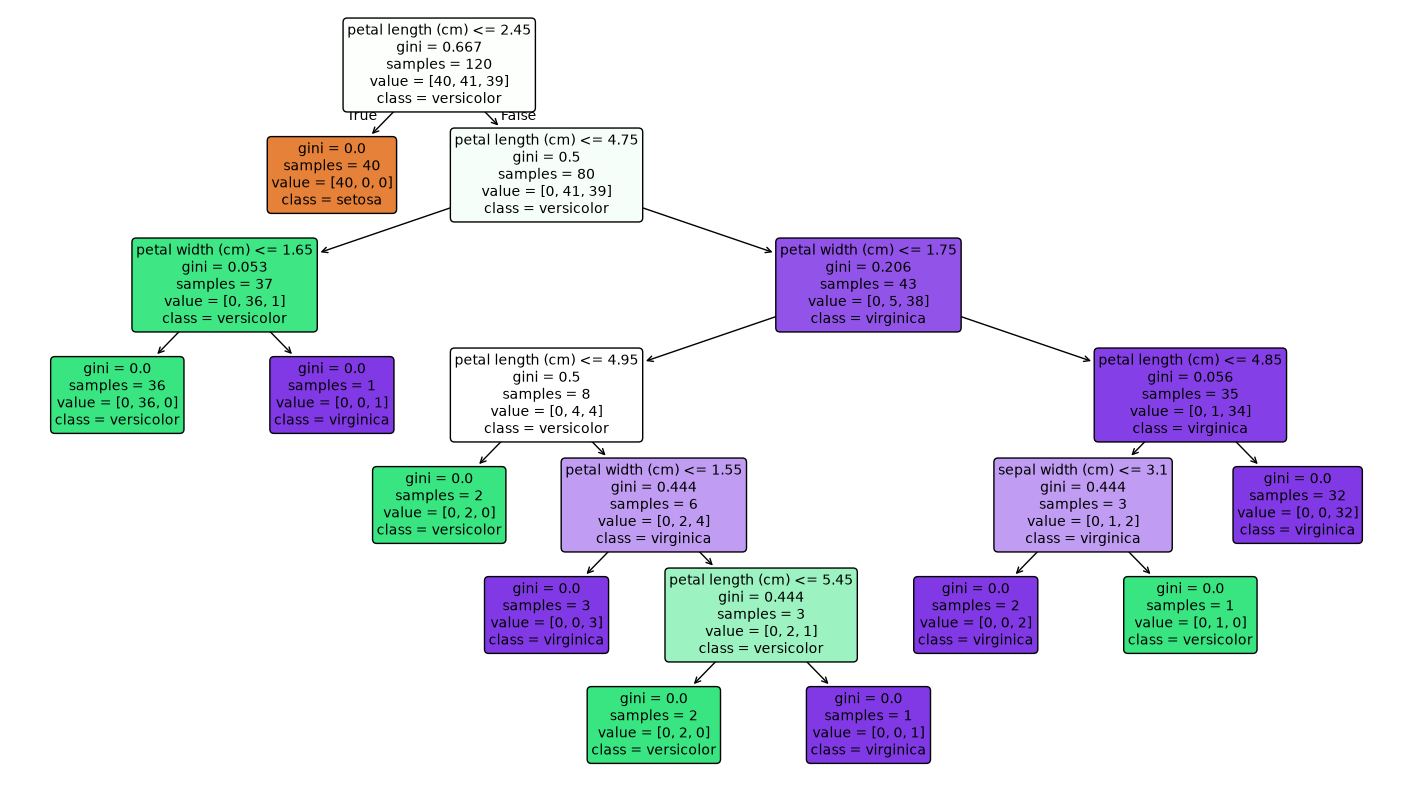

In [21]:
plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [22]:
print("Maximum Depth:", dt.get_depth())

Maximum Depth: 6


In [23]:
print("Number of Leaf Nodes:", dt.get_n_leaves())

Number of Leaf Nodes: 10


In [24]:
gini_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

gini_tree.fit(X_train, y_train)

gini_pred = gini_tree.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)

print("Gini Accuracy:", gini_accuracy)

Gini Accuracy: 1.0


In [25]:
entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

entropy_tree.fit(X_train, y_train)

entropy_pred = entropy_tree.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Entropy Accuracy:", entropy_accuracy)

Entropy Accuracy: 1.0


In [26]:
print("Gini Tree Depth:", gini_tree.get_depth())
print("Entropy Tree Depth:", entropy_tree.get_depth())

Gini Tree Depth: 6
Entropy Tree Depth: 6


In [27]:
print("Gini Leaf Nodes:", gini_tree.get_n_leaves())
print("Entropy Leaf Nodes:", entropy_tree.get_n_leaves())

Gini Leaf Nodes: 10
Entropy Leaf Nodes: 10


In [28]:
print("Gini Root Feature:",
      iris.feature_names[gini_tree.tree_.feature[0]])

print("Entropy Root Feature:",
      iris.feature_names[entropy_tree.tree_.feature[0]])

Gini Root Feature: petal length (cm)
Entropy Root Feature: petal length (cm)


In [29]:
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_accuracy, entropy_accuracy],
    "Tree Depth": [gini_tree.get_depth(), entropy_tree.get_depth()],
    "Leaf Nodes": [gini_tree.get_n_leaves(), entropy_tree.get_n_leaves()],
    "Root Feature": [
        iris.feature_names[gini_tree.tree_.feature[0]],
        iris.feature_names[entropy_tree.tree_.feature[0]]
    ]
})

comparison

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


In [30]:
depths = [1, 2, 3, 4, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        train_acc,
        test_acc,
        model.get_depth()
    ])

In [31]:
depth_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Training Accuracy",
        "Testing Accuracy",
        "Tree Depth"
    ]
)

depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1.0,0.675000,0.633333,1
1,2.0,0.950000,0.966667,2
2,3.0,0.958333,1.000000,3
3,4.0,0.975000,1.000000,4
4,NaN,1.000000,1.000000,6


In [32]:
observations = [
    "Very Simple Tree (Underfitting)",
    "Better Learning",
    "Good Generalization",
    "Complex Tree",
    "Fully Grown Tree (Possible Overfitting)"
]

depth_df["Observation"] = observations

depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.675000,0.633333,1,Very Simple Tree (Underfitting)
1,2.0,0.950000,0.966667,2,Better Learning
2,3.0,0.958333,1.000000,3,Good Generalization
3,4.0,0.975000,1.000000,4,Complex Tree
4,NaN,1.000000,1.000000,6,Fully Grown Tree (Possible Overfitting)


In [33]:
split_values = [2, 5, 10, 20]

results = []

for split in split_values:
    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [34]:
split_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Tree Depth",
        "Number of Leaf Nodes"
    ]
)

split_df


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes
0,2,1.0,6,10
1,5,1.0,5,8
2,10,1.0,4,6
3,20,1.0,4,6


In [35]:
observations = [
    "Default setting, complex tree",
    "Slightly simpler tree",
    "Simpler tree with good accuracy",
    "Very simple tree, may underfit"
]

split_df["Observation"] = observations

split_df

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,"Default setting, complex tree"
1,5,1.0,5,8,Slightly simpler tree
2,10,1.0,4,6,Simpler tree with good accuracy
3,20,1.0,4,6,"Very simple tree, may underfit"


In [36]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [37]:
leaf_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Number of Leaf Nodes"
    ]
)

leaf_df

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes
0,1,1.000000,6,10
1,2,1.000000,5,8
2,5,1.000000,4,6
3,10,0.966667,4,6


In [38]:
observations = [
    "Default setting, complex tree",
    "Slightly simpler tree",
    "Balanced tree with good accuracy",
    "Very simple tree, may underfit"
]

leaf_df["Observation"] = observations

leaf_df

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,"Default setting, complex tree"
1,2,1.000000,5,8,Slightly simpler tree
2,5,1.000000,4,6,Balanced tree with good accuracy
3,10,0.966667,4,6,"Very simple tree, may underfit"


In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [41]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [42]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

In [43]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [44]:
print("Best Cross Validation Score:")
print(grid.best_score_)

Best Cross Validation Score:
0.9583333333333334


In [45]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)

print("Optimized Model Accuracy:", best_accuracy)

Optimized Model Accuracy: 1.0


In [46]:
comparison = pd.DataFrame({
    "Model": ["Default Decision Tree", "Optimized Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, dt.predict(X_test)),
        best_accuracy
    ]
})

comparison

,Model,Accuracy
0,Default Decision Tree,1.0
1,Optimized Decision Tree,1.0
